In [9]:
import pandas as pd
import matplotlib.pyplot as plt

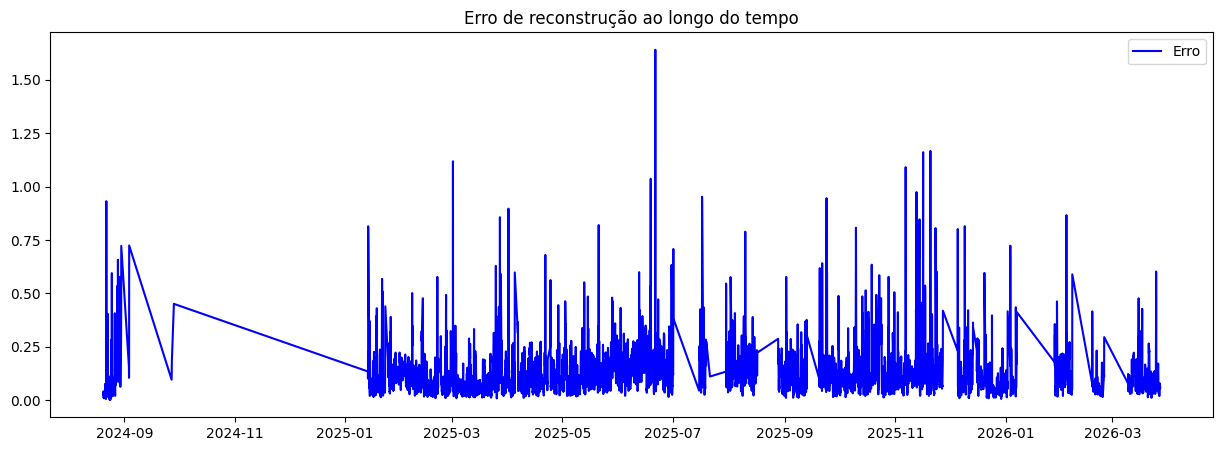

In [10]:
scores_df = pd.read_csv("../Dados/scores.csv", parse_dates=["Timestamp"], index_col="Timestamp")

plt.figure(figsize=(15,5))
plt.plot(scores_df.index, scores_df["reconstruction_error"], label="Erro", color="blue")

plt.legend()
plt.title("Erro de reconstrução ao longo do tempo")
plt.show()

In [11]:
scores_df.head()

,B-4064A: Corrente,B-4064A: Pressão Descarga,B-4064A: Pressão Sucção,B-4064A: Temperatura Mancal Bomba LA,B-4064A: Temperatura Mancal Bomba LNA,B-4064A: Temperatura Mancal Motor LA,B-4064A: Temperatura Mancal Motor LNA,B-4064A: Vib Mancal Bomba LNA,reconstruction_error,is_anomaly
Timestamp,,,,,,,,,,
2024-08-20 08:00:00,43.808869,30.780001,6.58,41.560000,46.260001,68.680000,63.600000,1.26492,0.033404,False
2024-08-20 09:00:00,44.337095,30.960001,6.42,43.800001,48.640001,69.000000,63.880001,1.23444,0.024649,False
2024-08-20 10:00:00,44.865321,31.140000,6.26,46.040001,51.020001,71.620001,66.020001,1.20396,0.029665,False
2024-08-20 11:00:00,45.393547,31.320000,6.10,48.160001,53.400002,74.240002,68.160002,1.17348,0.042712,False
2024-08-20 12:00:00,44.855644,31.500000,6.35,50.280001,54.700001,76.860003,70.300002,1.21666,0.014177,False


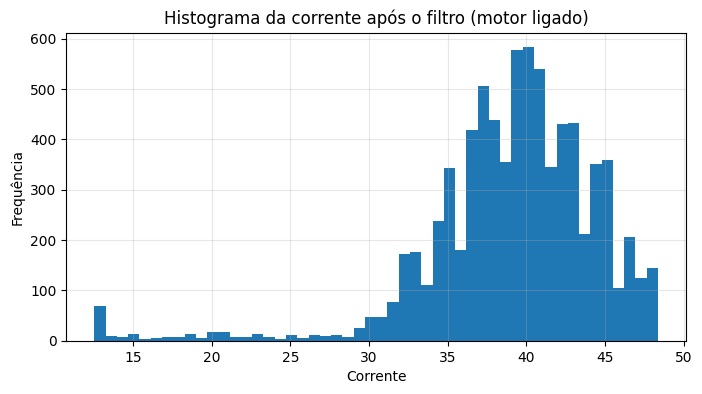

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(scores_df["B-4064A: Corrente"], bins=50)
plt.xlabel("Corrente")
plt.ylabel("Frequência")
plt.title("Histograma da corrente após o filtro (motor ligado)")
plt.grid(alpha=0.3)
plt.show()

In [13]:
scores_df.index = pd.to_datetime(scores_df.index)

In [14]:
def plot_all_sensors(df, start, end, threshold, falha):
    """
    Plota sempre a série.
    Só plota erro + falha se houver anomalias no período.
    """

    df_period = df.loc[start:end].copy()
    falha = pd.to_datetime(falha)

    anomalies = df_period[df_period["is_anomaly"] == True]

    sensor_cols = [
        col for col in df.columns
        if col not in ["reconstruction_error", "is_anomaly"]
    ]

    for sensor in sensor_cols:

        # 🔥 verifica se há anomalia para esse sensor
        sensor_anomalies = anomalies[~anomalies[sensor].isna()]
        has_anomaly = not sensor_anomalies.empty

        # 🔥 se NÃO tiver anomalia → só 1 gráfico
        if not has_anomaly:
            plt.figure(figsize=(15,4))

            plt.plot(df_period.index, df_period[sensor], label=sensor, color="blue")

            plt.title(f"{sensor} ({start} a {end})")
            plt.ylabel("Valor do Sensor")
            plt.legend()

            plt.tight_layout()
            plt.show()

        # 🔥 se tiver anomalia → gráfico completo
        else:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15,6), sharex=True)

            # sensor
            ax1.plot(df_period.index, df_period[sensor], label=sensor, color="blue")
            ax1.scatter(
                sensor_anomalies.index,
                sensor_anomalies[sensor],
                color="red",
                zorder=50,
                label="Anomalia"
            )
            ax1.axvline(x=falha, linestyle='--', color="red", label="Falha")
            ax1.set_ylabel("Valor do Sensor")
            ax1.set_title(f"{sensor} ({start} a {end})")
            ax1.legend()

            # erro
            ax2.plot(
                df_period.index,
                df_period["reconstruction_error"],
                color="green",
                label="Erro"
            )
            ax2.axhline(y=threshold, linestyle='--', color="orange", label="Threshold")
            ax2.axvline(x=falha, linestyle='--', color="red", label="Falha")
            ax2.set_ylabel("Erro de Reconstrução")
            ax2.set_xlabel("Timestamp")
            ax2.legend()

            plt.tight_layout()
            plt.show()

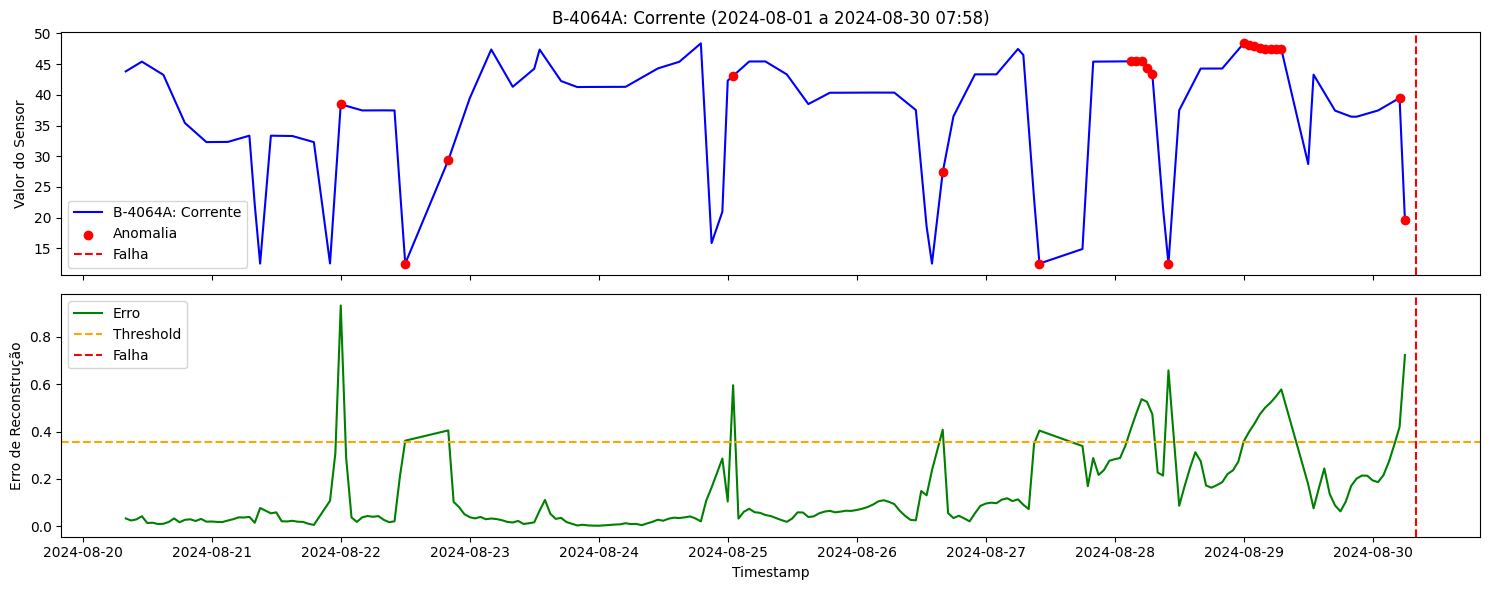

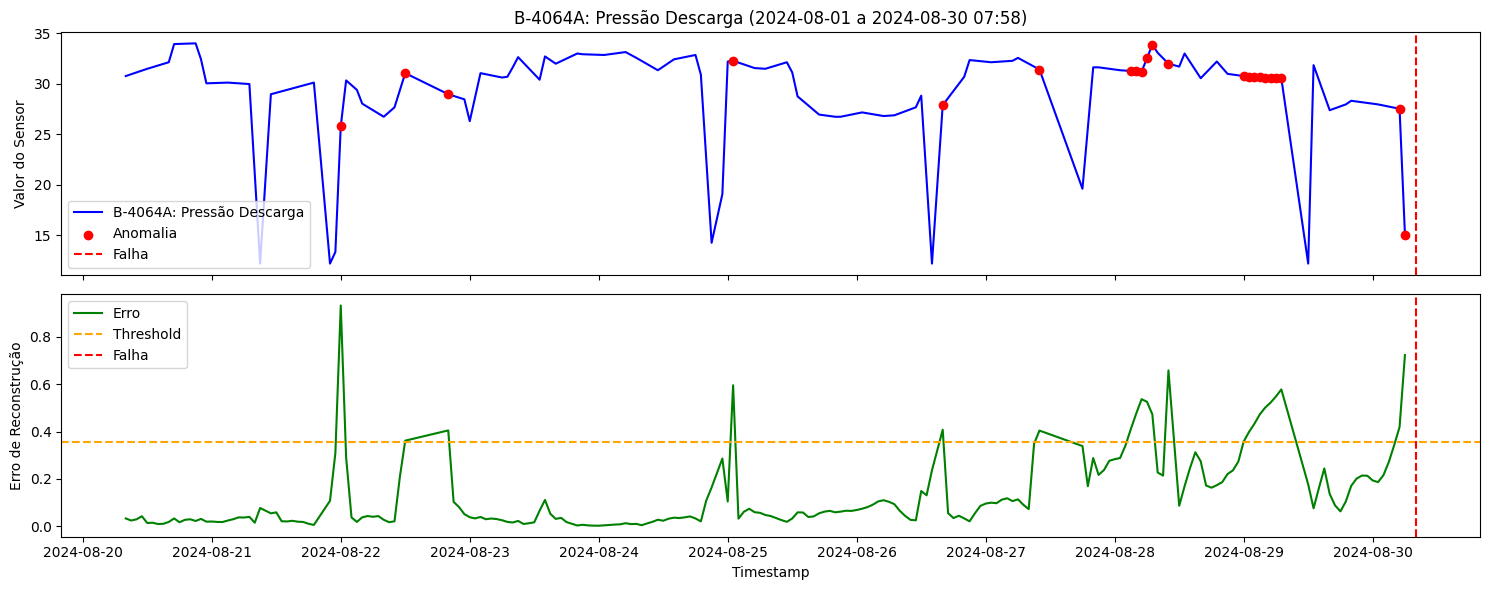

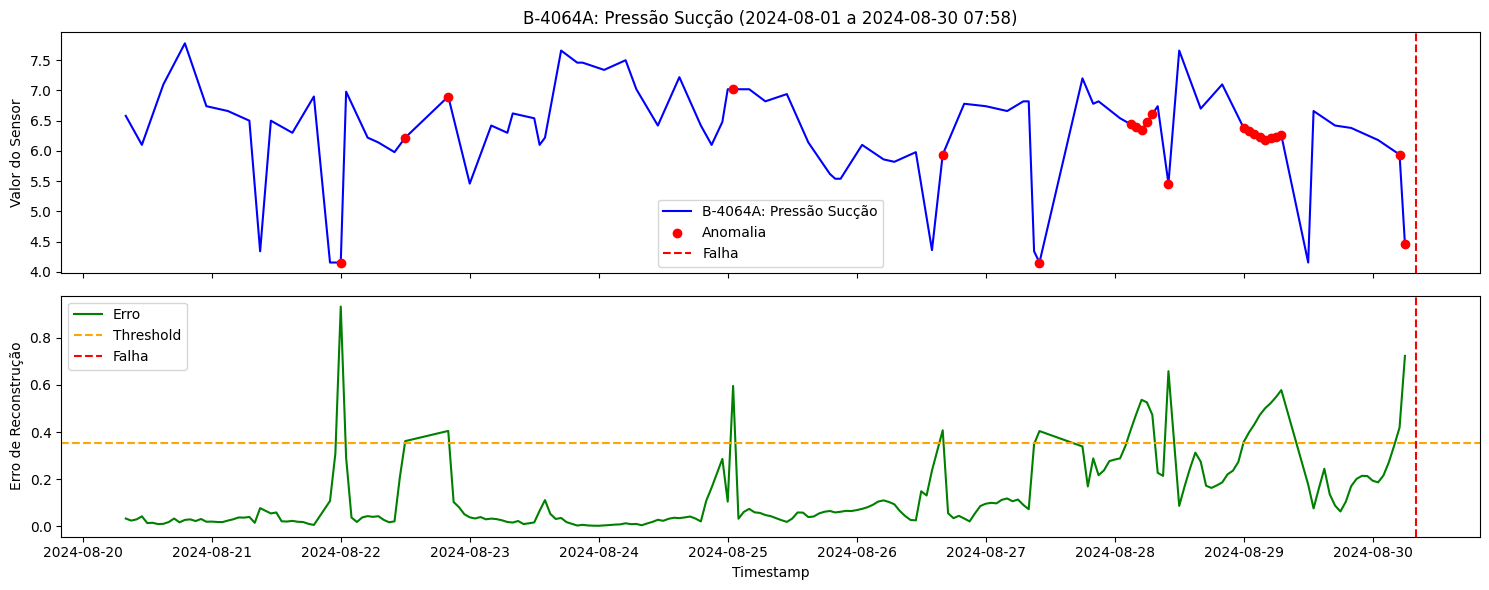

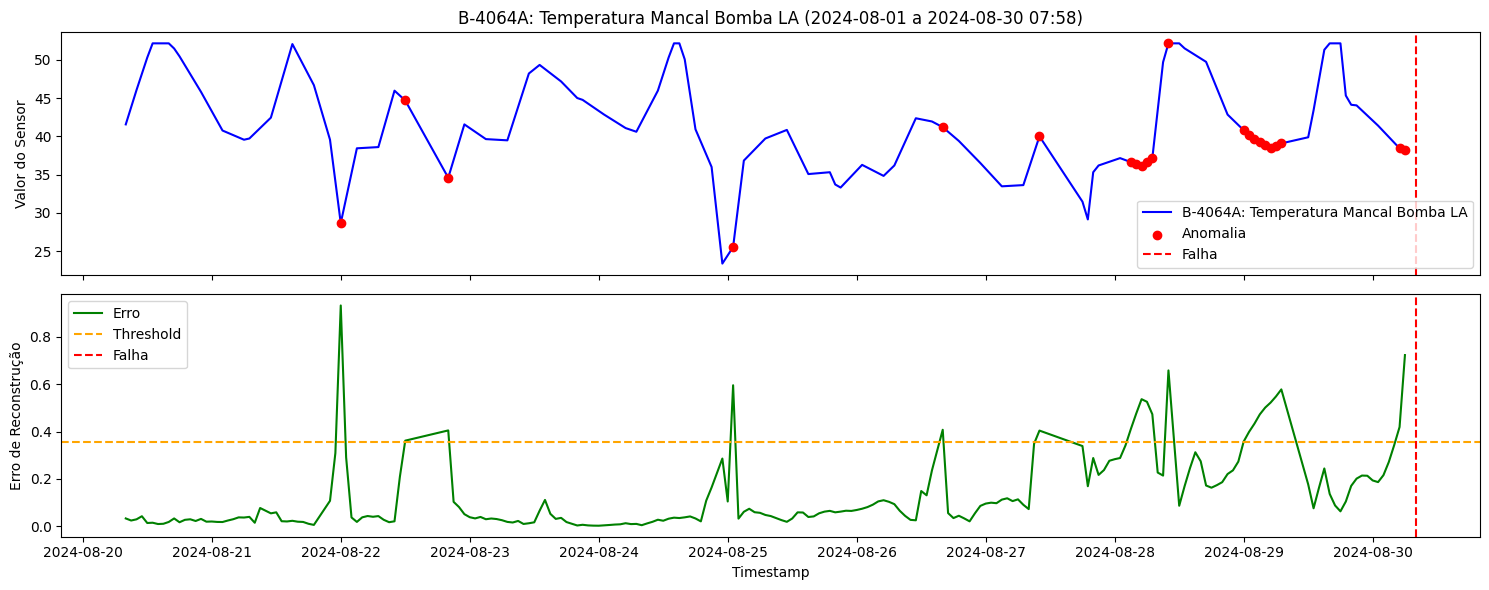

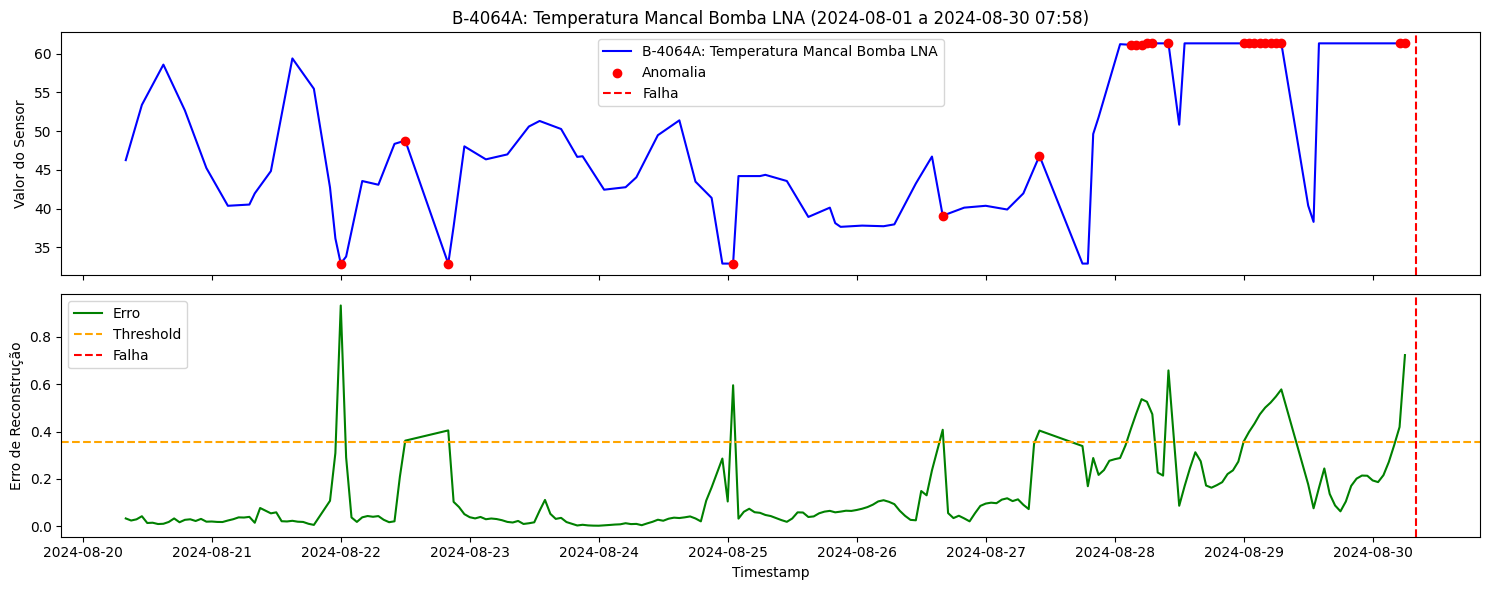

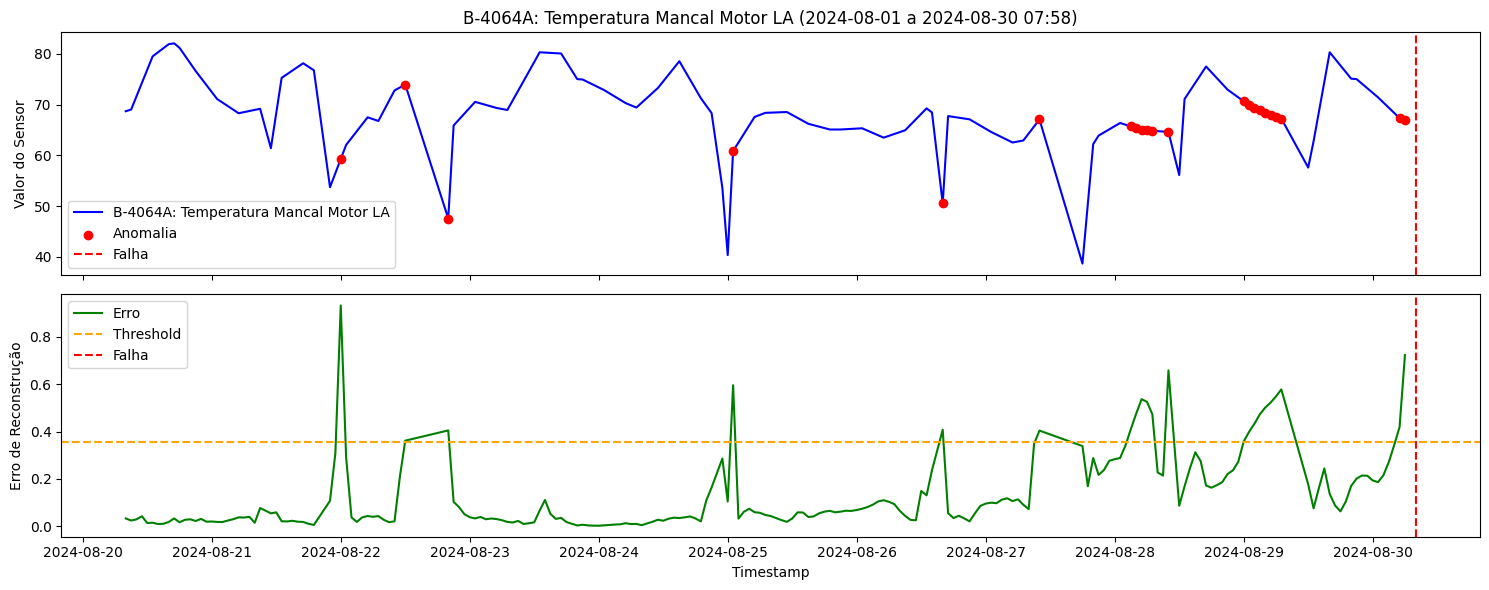

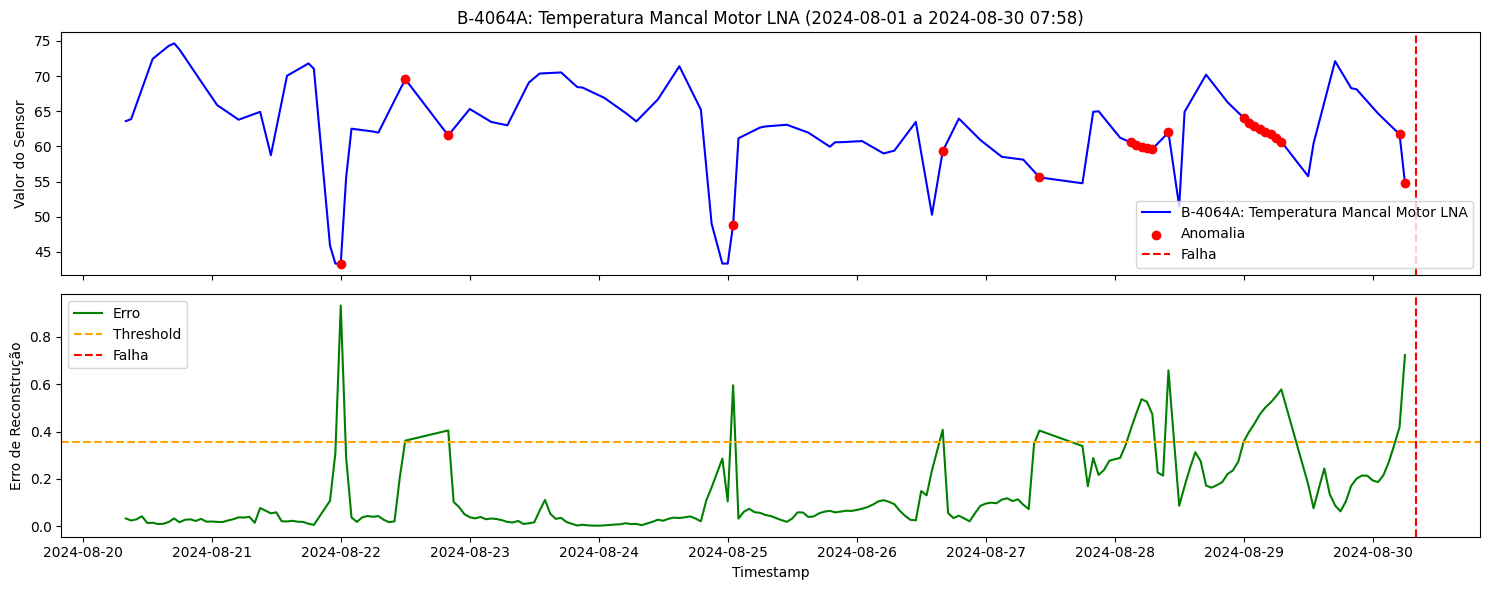

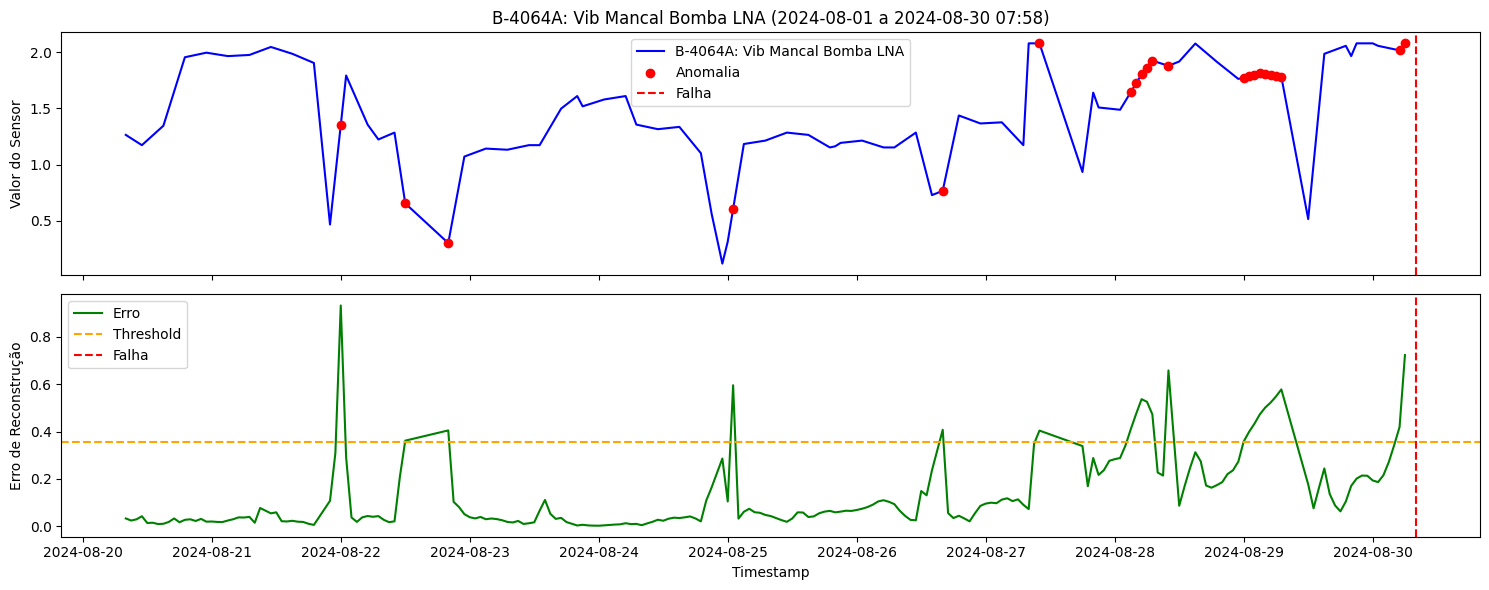

In [18]:
plot_all_sensors(scores_df, start="2024-08-01", end="2024-08-30 07:58", threshold=0.354424, falha="2024-08-30 07:58")

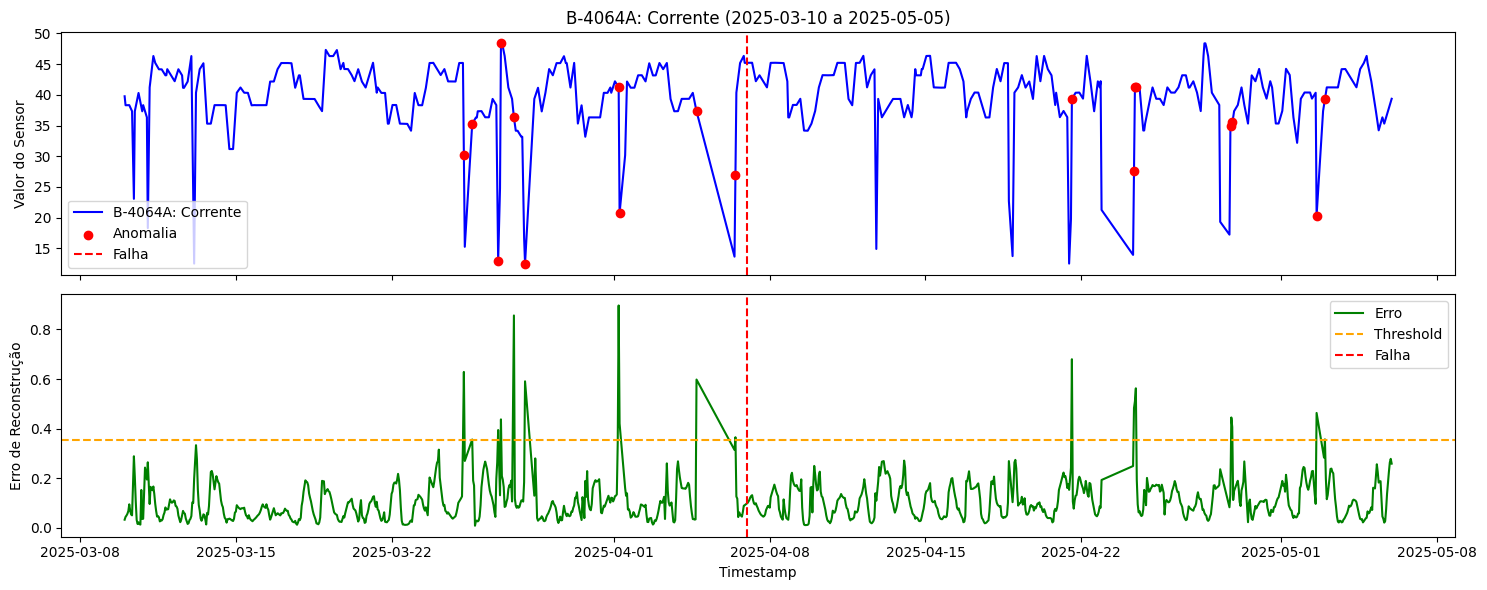

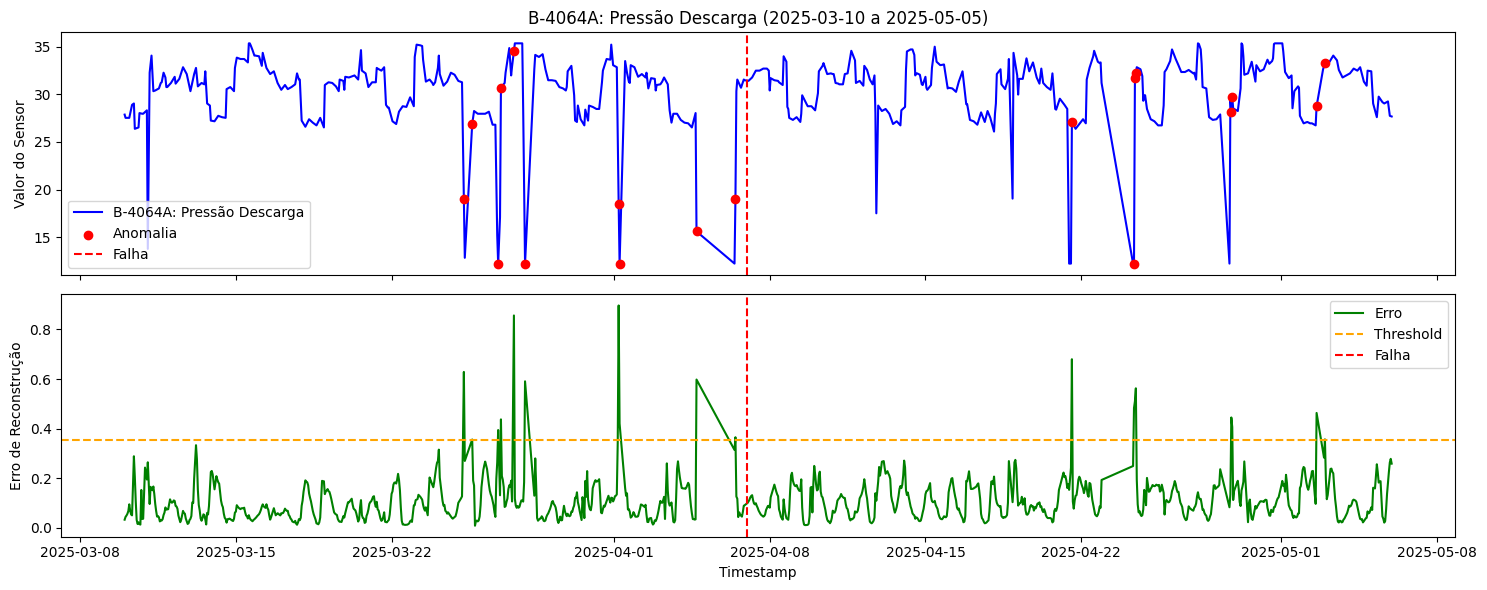

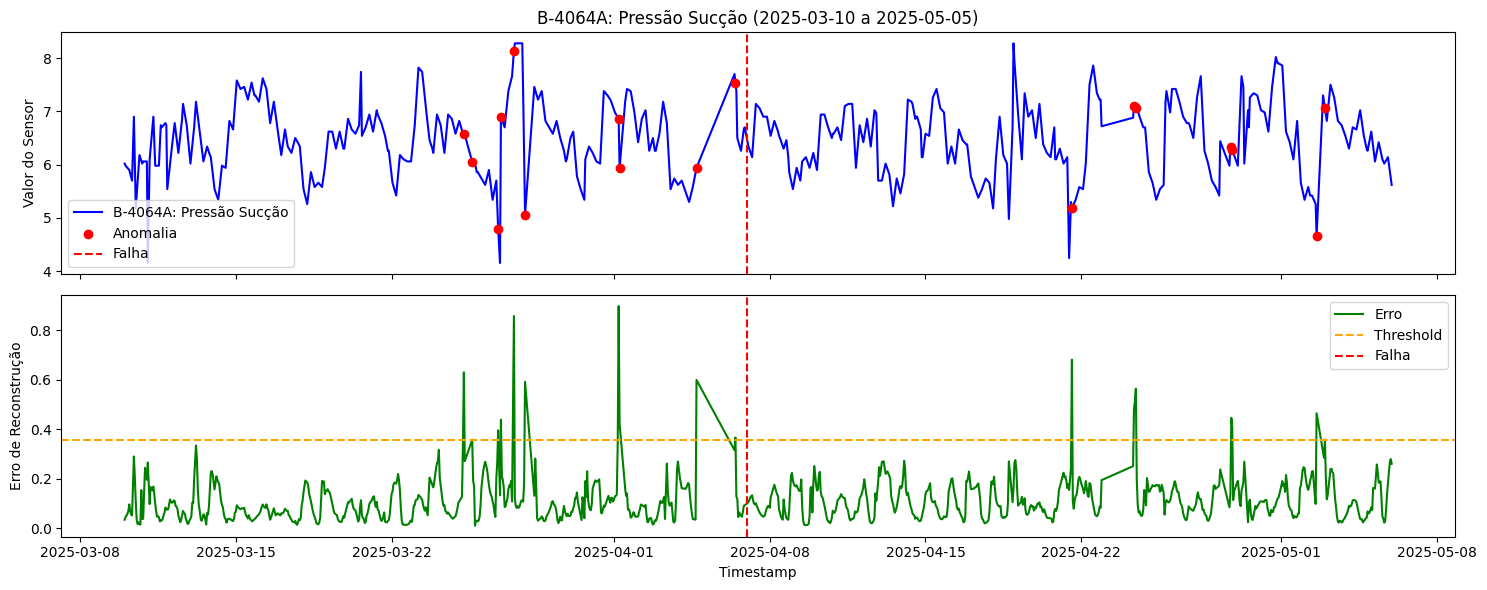

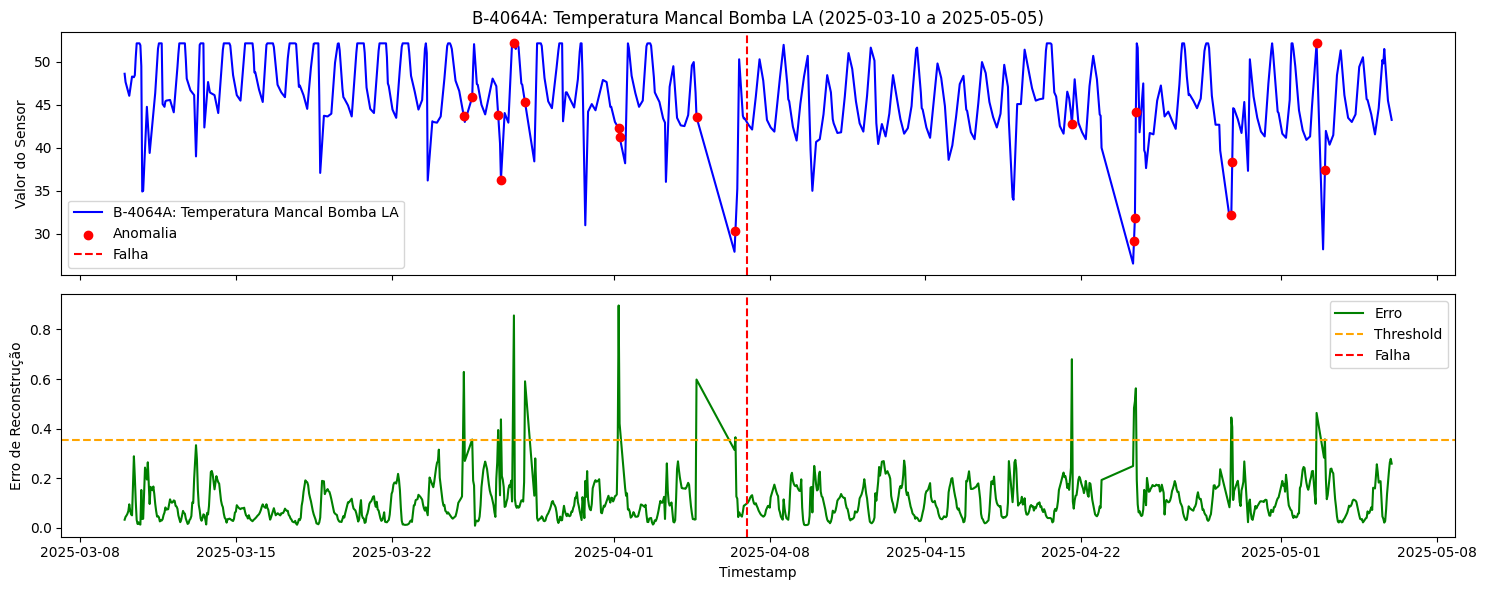

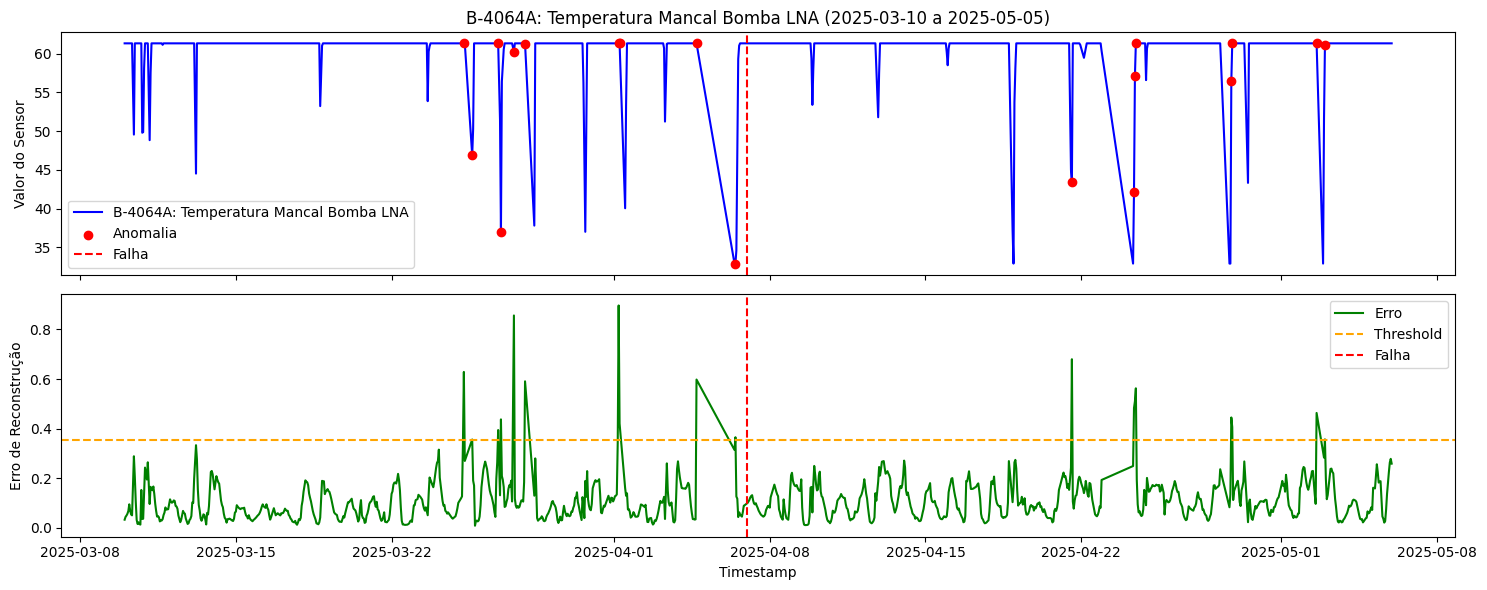

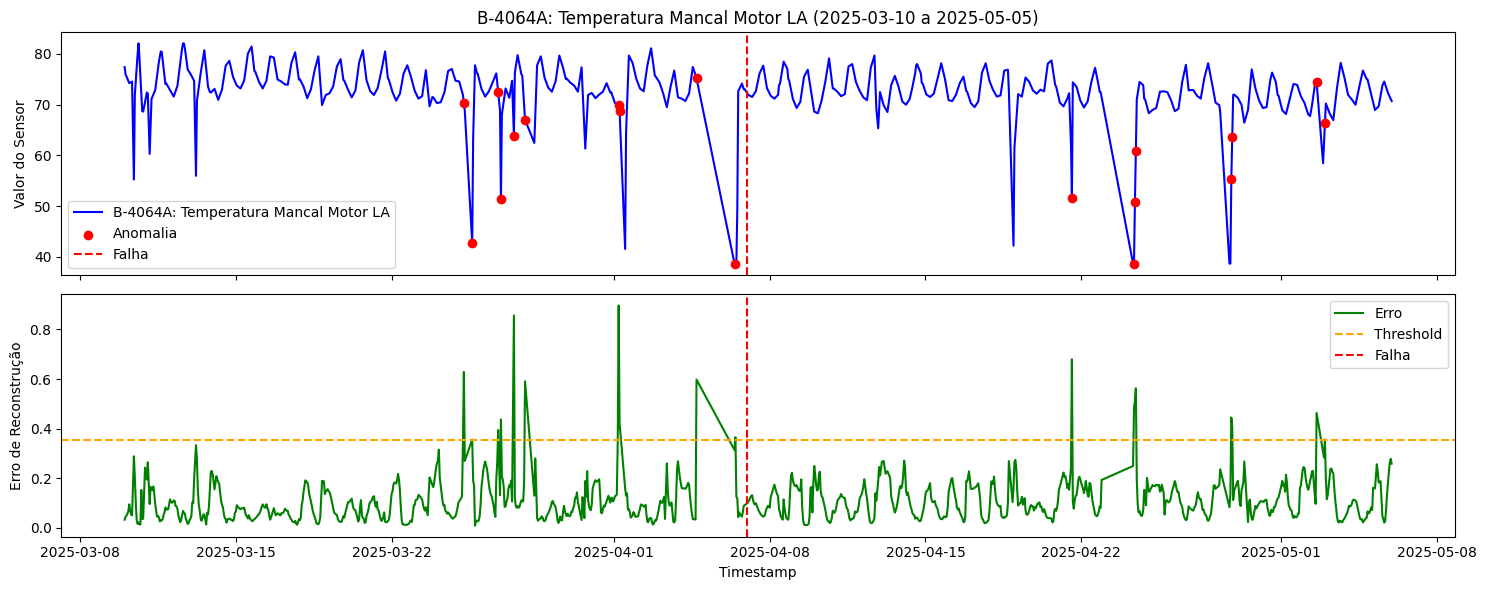

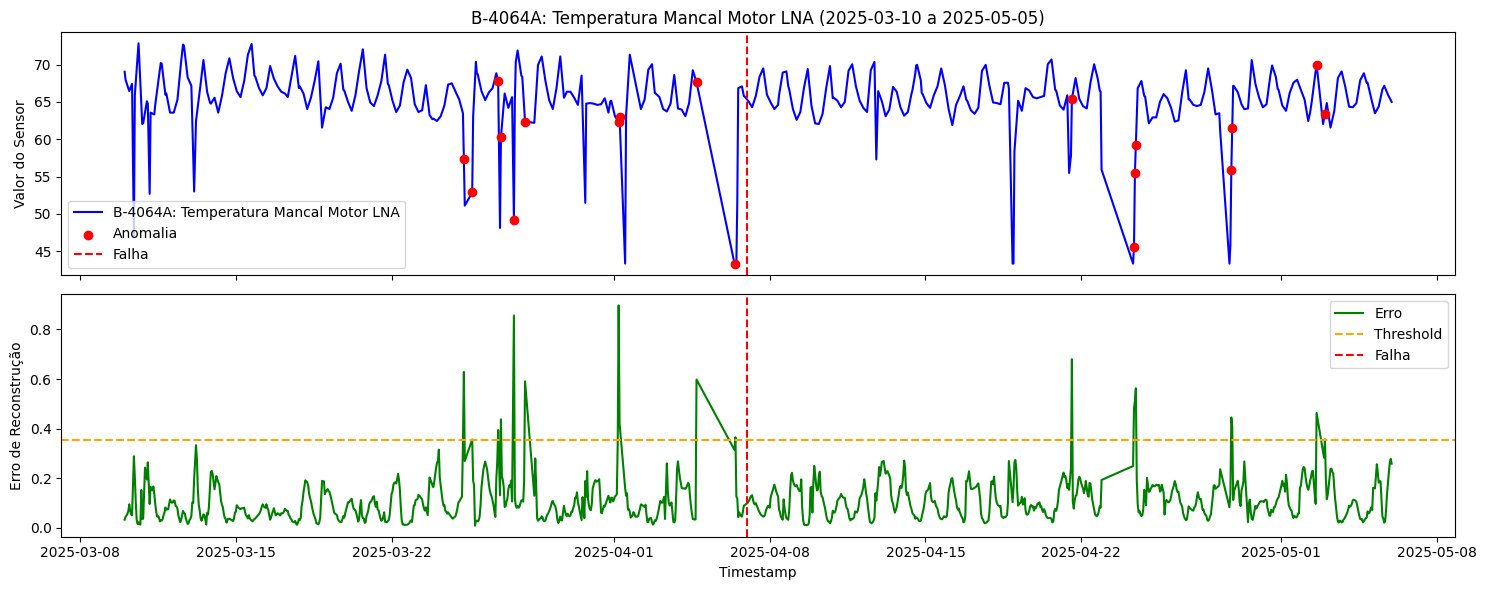

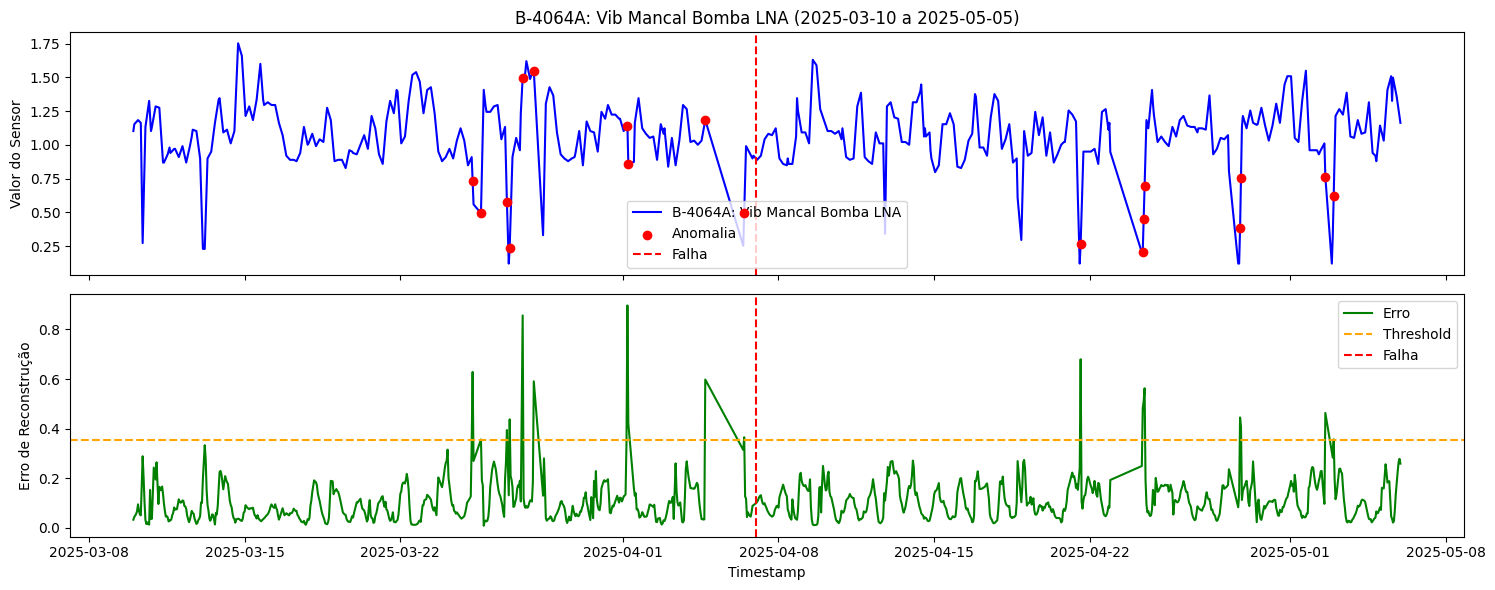

In [17]:
plot_all_sensors(scores_df, start="2025-03-10", end="2025-05-05", threshold=0.354424, falha="2025-04-07")